## Questão 2 - Segmentação por cor com K-Means

Pipeline: leitura → preparar dados de cor → escolher melhor k (cotovelo/silhueta) → segmentar → mostrar resultado.

In [7]:
import sys
sys.path.append("..")

from core import io_utils, kmeans_seg, visualization

CAMINHO_ENTRADA = "../data/input/onion.jpg"
CAMINHO_SAIDA = "../data/output/q2"

### Carregar imagem

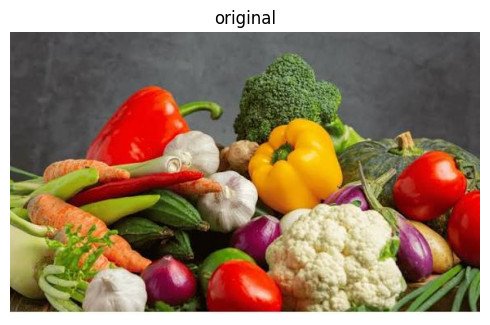

In [8]:
img = io_utils.carregar_imagem(CAMINHO_ENTRADA)
visualization.mostrar_lado_a_lado([img], ["original"])

### Escolher a melhor quantidade de clusters

In [9]:
dados = kmeans_seg.preparar_dados_kmeans(img)
k = kmeans_seg.escolher_melhor_k(dados, k_min=2, k_max=10, metodo="elbow")
print("k escolhido (cotovelo):", k)

c:\Users\João Victor\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\João Victor\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\João Victor\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\João Victor\AppData\Local\Programs\Pyth

k escolhido (cotovelo): 5


### Visualizando a curva do cotovelo

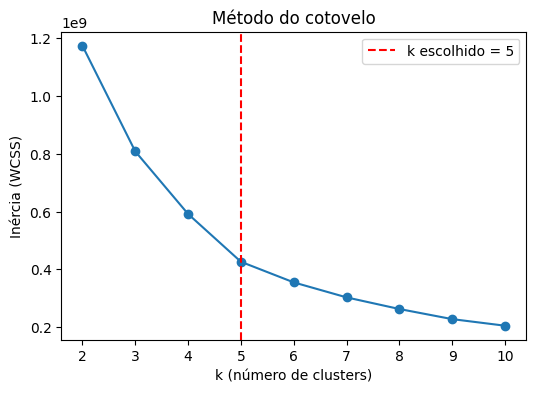

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

valores_k = list(range(2, 11))
inercias = [KMeans(n_clusters=kk, n_init=10, random_state=42).fit(dados).inertia_ for kk in valores_k]

plt.figure(figsize=(6, 4))
plt.plot(valores_k, inercias, "o-")
plt.axvline(k, color="red", linestyle="--", label=f"k escolhido = {k}")
plt.xlabel("k (número de clusters)")
plt.ylabel("Inércia (WCSS)")
plt.title("Método do cotovelo")
plt.legend()
plt.show()

### Segmentar e mostrar o resultado

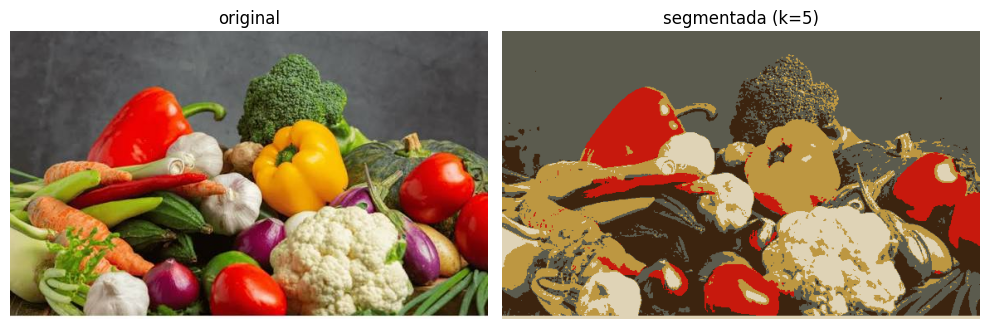

In [11]:
img_segmentada = kmeans_seg.segmentar_kmeans(img, k)
visualization.mostrar_lado_a_lado([img, img_segmentada], ["original", f"segmentada (k={k})"])
io_utils.salvar_imagem(f"{CAMINHO_SAIDA}/segmentada_k{k}.png", img_segmentada)

### Extra - Comparando com os vizinhos

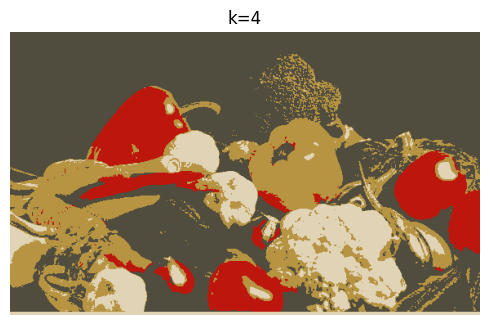

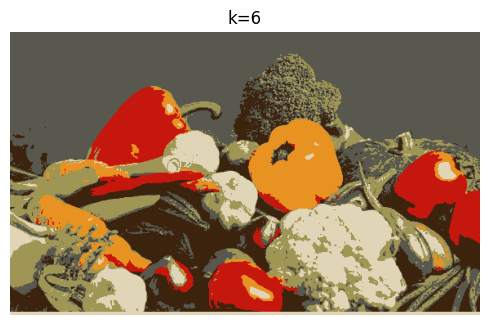

In [17]:
for k_teste in [k - 1, k + 1]:
    seg = kmeans_seg.segmentar_kmeans(img, k_teste)
    visualization.mostrar_lado_a_lado([seg], [f"k={k_teste}"])